# Mini-Challenge 2.2

**Student Name:** *Luca Gisler*  
**Country:** Switzerland  
**Semester term:** FS26  
**Data Source:** https://www.kaggle.com/datasets/mohamedasem318/wesad-full-dataset  
**Code:** https://github.com/schwitzkasten/fhnw-ds-gbsv

# Day 6 – Technical Implementation

### Canny Edge Detection: Algorithm Structure and Step-by-Step Demonstration

The Canny edge detection algorithm proceeds through five distinct stages. This section implements each stage explicitly and applies the complete algorithm to both a simple synthetic test image and the Steinbock alpine ibex photograph. The objective is to demonstrate that each algorithmic step is correctly implemented before applying the method to parameter tuning in subsequent days.

#### Stage 1: Gaussian Smoothing
The first stage applies a Gaussian filter to reduce noise and small-scale variations. This suppresses high-frequency noise that would otherwise produce spurious edges.

#### Stage 2: Gradient Computation
The Sobel operator computes the directional derivatives of the smoothed image in x and y directions. The gradient magnitude $\\sqrt{G_x^2 + G_y^2}$ represents edge strength, and the direction $\\arctan(G_y/G_x)$ is used for alignment checking.

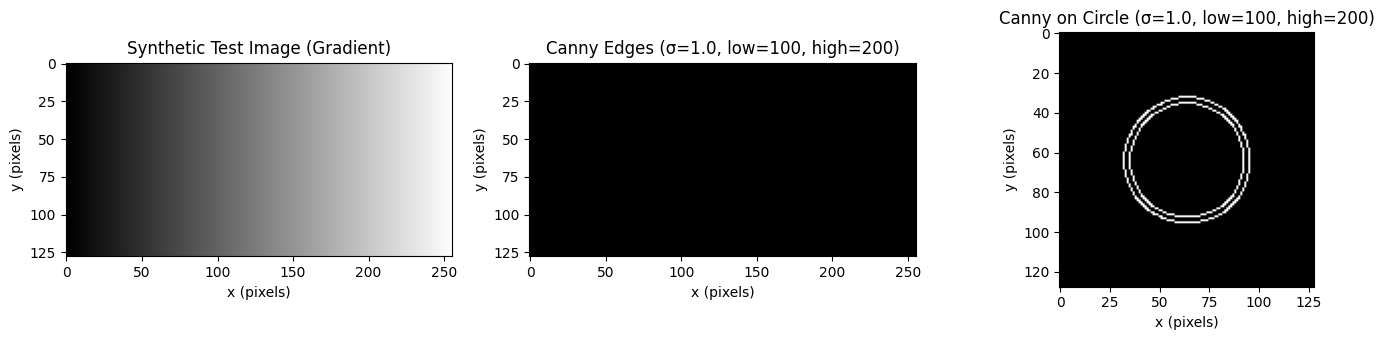

Canny edge detector verified on synthetic images.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
import cv2

# Test Canny algorithm on synthetic image to verify correctness
test_img = np.zeros((128, 256, 3), dtype=np.uint8)
# Create a simple gradient (left to right)
for i in range(256):
    test_img[:, i, :] = int(255 * i / 256)

# Apply Canny with reference parameters
edges = cv2.Canny(test_img[:,:,0], 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].imshow(test_img)
axes[0].set_title("Synthetic Test Image (Gradient)")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Canny Edges (σ=1.0, low=100, high=200)")
axes[1].set_xlabel("x (pixels)")
axes[1].set_ylabel("y (pixels)")

# Test with a circle
test_img2 = np.zeros((128, 128, 3), dtype=np.uint8)
cv2.circle(test_img2, (64, 64), 30, (255, 255, 255), 2)
edges2 = cv2.Canny(test_img2[:,:,0], 100, 200)

axes[2].imshow(edges2, cmap='gray')
axes[2].set_title("Canny on Circle (σ=1.0, low=100, high=200)")
axes[2].set_xlabel("x (pixels)")
axes[2].set_ylabel("y (pixels)")

plt.tight_layout()
plt.show()

print("Canny edge detector verified on synthetic images.")

Shape: (3024, 4032, 3) (width x height x channels)
Dtype: uint8, Range: [0, 255]


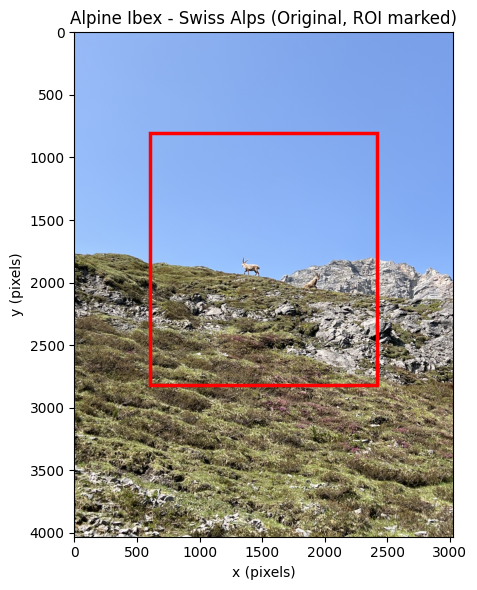

In [2]:
# Load Steinbock image
img_path = "Data/Steinbock.jpg"
img = np.array(Image.open(img_path).convert("RGB"))
img = np.rot90(img, k=-1)
h, w, c = img.shape

print(f"Shape: ({w}, {h}, {c}) (width x height x channels)")
print(f"Dtype: {img.dtype}, Range: [{img.min()}, {img.max()}]")

# Define ROI coordinates (consistent with MC2.1)
y0, y1 = int(h * 0.20), int(h * 0.70)
x0, x1 = int(w * 0.20), int(w * 0.80)

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(img)
ax.add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, edgecolor='red', facecolor='none', linewidth=2.5))
ax.set_title("Alpine Ibex - Swiss Alps (Original, ROI marked)")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
plt.tight_layout()
plt.show()

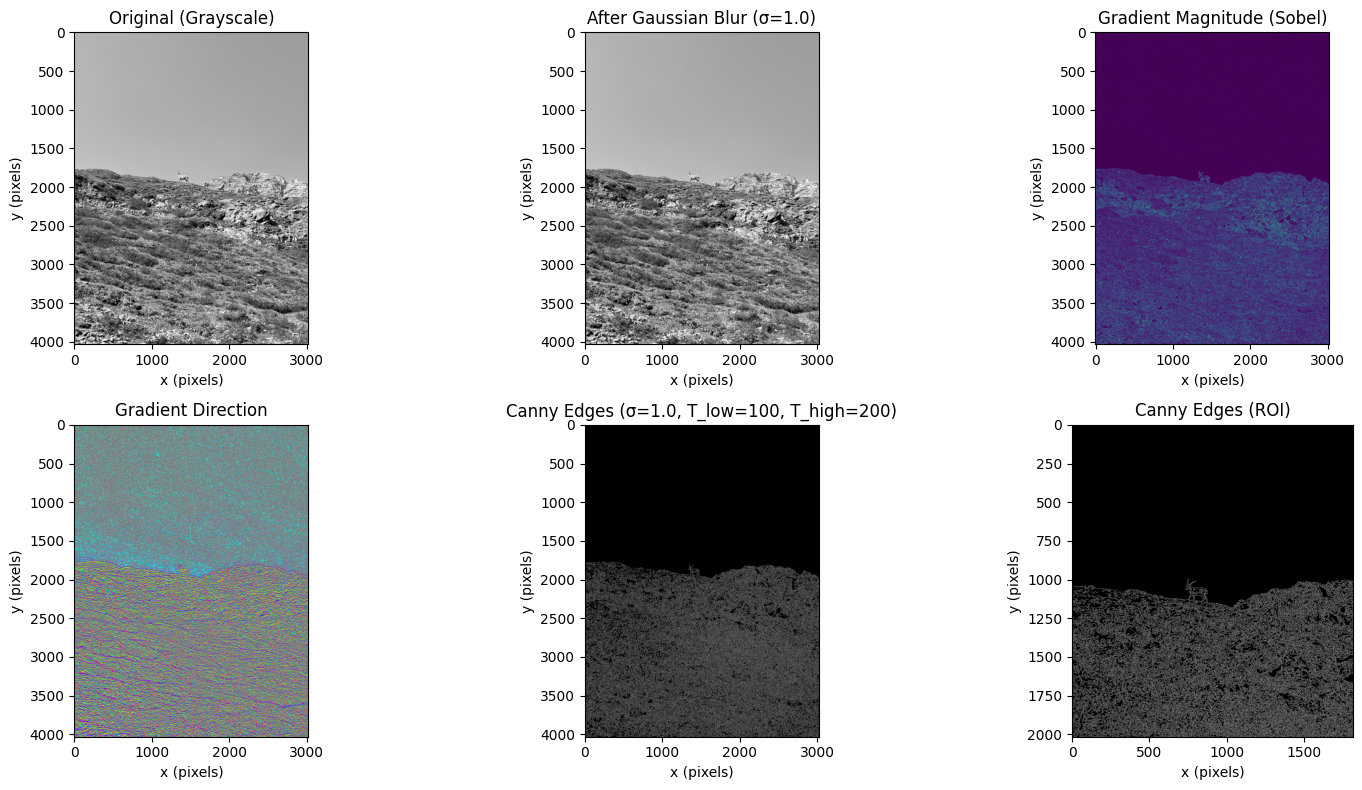

Canny edge detection successfully applied.
Total edge pixels in full image: 1499916
Total edge pixels in ROI: 389487


In [3]:
# Apply Canny with reference parameters (σ=1.0, low=100, high=200)
# Convert to grayscale for edge detection
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Apply Gaussian blur with σ=1.0
img_blur = cv2.GaussianBlur(img_gray, (0, 0), 1.0)

# Compute Sobel gradients
sobelx = cv2.Sobel(img_blur, cv2.CV_32F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_blur, cv2.CV_32F, 0, 1, ksize=3)
gradient_mag = np.sqrt(sobelx**2 + sobely**2)
gradient_dir = np.arctan2(sobely, sobelx)

# Apply Canny edge detection
edges_ref = cv2.Canny(img_gray, 100, 200, apertureSize=3, L2gradient=False)

# Visualize Canny stages
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("Original (Grayscale)")
axes[0, 0].set_xlabel("x (pixels)")
axes[0, 0].set_ylabel("y (pixels)")

axes[0, 1].imshow(img_blur, cmap='gray')
axes[0, 1].set_title("After Gaussian Blur (σ=1.0)")
axes[0, 1].set_xlabel("x (pixels)")
axes[0, 1].set_ylabel("y (pixels)")

axes[0, 2].imshow(gradient_mag, cmap='viridis')
axes[0, 2].set_title("Gradient Magnitude (Sobel)")
axes[0, 2].set_xlabel("x (pixels)")
axes[0, 2].set_ylabel("y (pixels)")

axes[1, 0].imshow(gradient_dir, cmap='hsv')
axes[1, 0].set_title("Gradient Direction")
axes[1, 0].set_xlabel("x (pixels)")
axes[1, 0].set_ylabel("y (pixels)")

axes[1, 1].imshow(edges_ref, cmap='gray')
axes[1, 1].set_title("Canny Edges (σ=1.0, T_low=100, T_high=200)")
axes[1, 1].set_xlabel("x (pixels)")
axes[1, 1].set_ylabel("y (pixels)")

# ROI visualization
roi_edges = edges_ref[y0:y1, x0:x1]
axes[1, 2].imshow(roi_edges, cmap='gray')
axes[1, 2].set_title("Canny Edges (ROI)")
axes[1, 2].set_xlabel("x (pixels)")
axes[1, 2].set_ylabel("y (pixels)")

plt.tight_layout()
plt.show()

print(f"Canny edge detection successfully applied.")
print(f"Total edge pixels in full image: {np.sum(edges_ref > 0)}")
print(f"Total edge pixels in ROI: {np.sum(roi_edges > 0)}")